# 데이터 시각화 심화

- plt.title() - 그래프 제목
- plt.xlabel() - x축 이름
- plt.ylabel() - y축 이름
- plt.legend() - 범례
- plt.grid() - 보조선
- plt.figure(figsize=(가로, 세로)) - 그래프 크기

In [27]:
import matplotlib.pyplot as plt
import matplotlib
import platform

# 한글이 깨지는 경우, 운영체제 맞게 한글 폰트 지정
if platform.system() == "Windows":
    # 윈도우: 맑은 고딕
    matplotlib.rc("font", family = "Malgun Gothic")
elif platform.system() == "Darwin":
    # 맥: 애플 고딕
    matplotlib.rc("font", family = "AppleGothic")
else:
    # 리눅스: 나눔 고딕
    matplotlib.rc("font", family = "NanumGothic")

# 마이너스 깨짐 방지
matplotlib.rc("axes", unicode_minus=False)

print("matplotlib 준비 완료")
print("현재 os: ", platform.system())

matplotlib 준비 완료
현재 os:  Windows


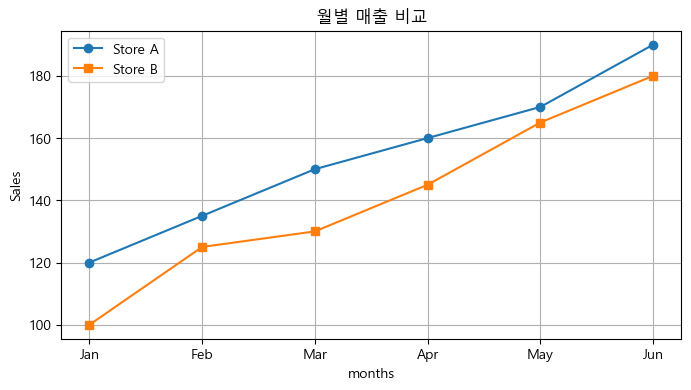

In [28]:
# Monthly sales

import pandas as pd
import matplotlib.pyplot as plt

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales_a = [120, 135, 150, 160, 170, 190]
sales_b = [100, 125, 130, 145, 165, 180]

plt.figure(figsize=(8,4))
plt.plot(months, sales_a, marker="o", label="Store A")
plt.plot(months, sales_b, marker="s", label="Store B")
plt.title("월별 매출 비교")
plt.xlabel("months")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## 히스토그램

> 숫자 데이터가 어느 구간에 많이 모여있는지 보여주는 그래프

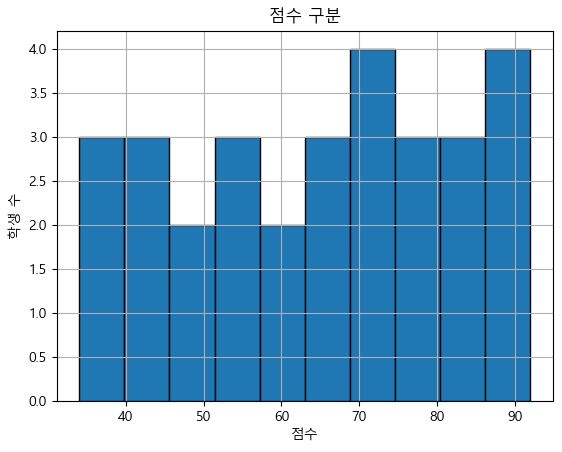

In [29]:
scores = [
    45, 72, 88, 63, 51, 79, 34, 92, 67, 58,
    83, 41, 76, 55, 69, 87, 48, 73, 62, 91,
    37, 84, 56, 78, 44, 65, 82, 53, 71, 39
]

plt.Figure(figsize=(8, 4))  # 그래프 크기 설정 (가로 8, 세로 4)
plt.hist(scores, bins=10, edgecolor="black")  # 히스토그램 생성, bins: 구간 수, edgecolor: 막대 테두리 색
plt.title("점수 구분")  # 그래프 제목
plt.xlabel("점수")  # x축 이름
plt.ylabel("학생 수")  # y축 이름
plt.grid(True)  # 보조선 표시
plt.show()  # 그래프 출력

# 파이차트

> 전체 중에 각 항목이 차지하는 비율을 보여주는 그래프

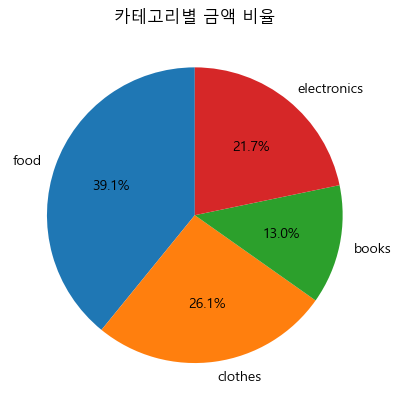

In [30]:
category_sales = pd.DataFrame({
    "category":["food", "clothes", "books", "electronics"],
    "sales": [450, 300, 150, 250]
})

plt.Figure(figsize=(6,6))  # 그래프 크기 설정 (가로 6, 세로 6)
plt.pie(
    category_sales["sales"],             # 비율로 사용할 값
    labels=category_sales["category"],  # 각 항목 이름
    startangle=90,                       # 시작 각도 (12시 방향부터)
    autopct="%.1f%%"                     # 각 항목에 비율(소수 1자리) 표시
)

plt.title("카테고리별 금액 비율")  # 그래프 제목
plt.show()  # 그래프 출력

# 히트맵

> 숫자의 크기를 색의 진하기로 표현하는 그래프, 상관계수를 히트맵으로 확인

In [31]:
student_data = pd.DataFrame({
    "study_houurs": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "attendance": [50, 55, 60, 65, 70, 75 ,80, 85 ,90, 95],
    "assignment": [40, 50, 55, 60, 70, 75, 78, 85, 88, 92],
    "score": [45, 52, 58, 65, 72, 78, 82, 88, 93, 97]
})

corr = student_data.corr()  # 각 컬럼 간의 상관계수 계산 (-1 ~ 1, 1에 가까울수록 강한 양의 상관관계)
corr

,study_houurs,attendance,assignment,score
study_houurs,1.000000,1.000000,0.991318,0.996872
attendance,1.000000,1.000000,0.991318,0.996872
assignment,0.991318,0.991318,1.000000,0.997569
score,0.996872,0.996872,0.997569,1.000000


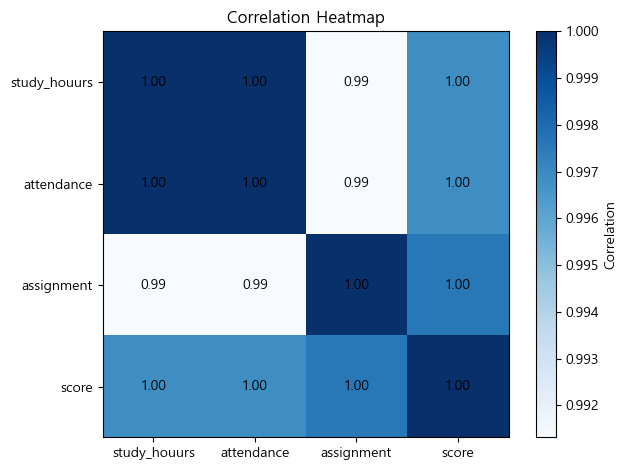

In [32]:
plt.Figure(figsize=(5, 4))  # 그래프 크기 설정
plt.imshow(corr, cmap="Blues")  # 상관계수 행렬을 색상으로 시각화 (값이 클수록 진한 파란색)
plt.colorbar(label="Correlation")  # 색상 기준 바 표시
plt.title("Correlation Heatmap")  # 그래프 제목
plt.xticks(range(len(corr.columns)), corr.columns)  # x축 눈금을 컬럼 이름으로 설정
plt.yticks(range(len(corr.columns)), corr.columns)  # y축 눈금을 컬럼 이름으로 설정

# 각 칸에 숫자 표시
for row in range(len(corr.columns)):      # 행(y축) 순회
    for col in range(len(corr.columns)):  # 열(x축) 순회
        plt.text(col, row, f"{corr.iloc[row, col]:.2f}", ha="center", va="center")  # 해당 위치에 상관계수 텍스트 출력

plt.tight_layout()  # 레이아웃 자동 정렬 (요소 겹침 방지)
plt.show()  # 그래프 출력